# Calories Burn Prediction — Complete Machine Learning Project

## Goal
Build a complete **supervised regression project** that predicts `Calories` burned from exercise/user measurements.

**Dataset:** 15,000 rows and 9 columns.  
**Target:** `Calories`  
**Identifier:** `User_ID`

### Complete workflow
**EDA → cleaning → train/test split → preprocessing → baseline → regression algorithms → comparison → cross-validation → tuning → feature engineering → leakage audit → final model → saving → prediction → interpretation**

> This notebook is fully completed with easy-to-read code, short comments, and answers to the questions.

## 1. Import Libraries

We import only the libraries needed for this project.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, FunctionTransformer

# Data splitting and validation
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV
)

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression models
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

# Saving the final model
import joblib

# Reproducibility
RANDOM_STATE = 42

## 2. Load the Dataset

The CSV file should be named `calories.csv` and should be in the same folder as this notebook.

In [2]:
# Load the dataset
df = pd.read_csv("calories.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (15000, 9)


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [3]:
# Inspect the last rows, columns, and data types
display(df.tail())
print("Columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0
14999,11751526,male,63,173.0,79.0,18.0,92.0,40.5,98.0


Columns: ['User_ID', 'Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']

Data types:
User_ID         int64
Gender         object
Age             int64
Height        float64
Weight        float64
Duration      float64
Heart_Rate    float64
Body_Temp     float64
Calories      float64
dtype: object


In [4]:
# Check memory usage and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


### Dataset questions and answers

**Q1. What is the target column?**  
**Answer:** `Calories`, because it is the value we want to predict.

**Q2. Which column looks like an identifier?**  
**Answer:** `User_ID`. It uniquely identifies a record and normally should not be used as a predictive feature.

**Q3. Which columns are numerical?**  
**Answer:** `Age`, `Height`, `Weight`, `Duration`, `Heart_Rate`, `Body_Temp`, and `Calories`.

**Q4. Which column is categorical?**  
**Answer:** `Gender`.

## 3. Understand the Dataset

We check:
- descriptive statistics
- unique values
- missing values
- duplicate rows
- duplicate IDs

In [5]:
# Descriptive statistics
display(df.describe())

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [6]:
# Unique values in each column
print(df.nunique())

User_ID       15000
Gender            2
Age              60
Height           90
Weight           91
Duration         30
Heart_Rate       59
Body_Temp        45
Calories        277
dtype: int64


In [7]:
# Missing values
print(df.isnull().sum())

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64


In [8]:
# Duplicate rows and duplicate IDs
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate User_ID:", df["User_ID"].duplicated().sum())

Duplicate rows: 0
Duplicate User_ID: 0


### Dataset quality answers

- **Missing values:** The provided notebook inspection shows no missing values.
- **Duplicate rows:** The provided notebook found one duplicate after `User_ID` was removed; therefore duplicates should be checked after removing the identifier too.
- **Duplicate `User_ID`:** The provided notebook found 0 duplicate IDs.
- **Target type:** `Calories` is a continuous numerical target, so this is a **regression** problem.
- **Suspicious values:** The observed ranges are plausible for this exercise dataset. We should still inspect plots before automatically removing anything.

## 4. Exploratory Data Analysis (EDA)

EDA helps us understand distributions, relationships, outliers, and possible patterns before modeling.

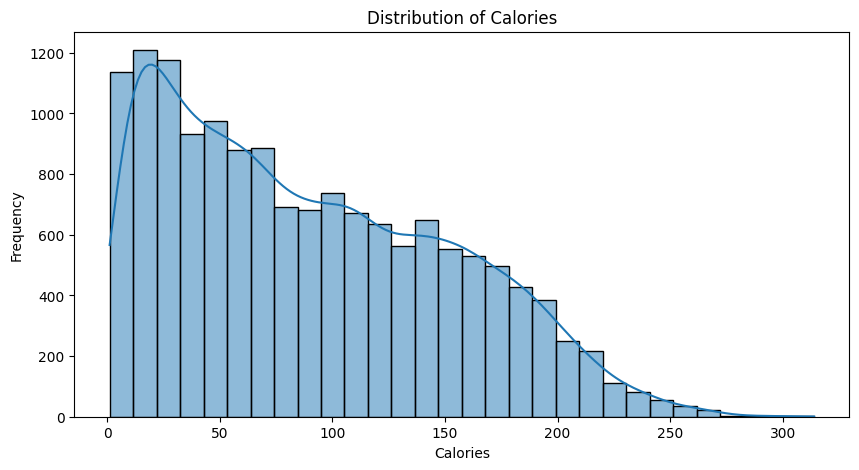

In [9]:
# Define numerical columns
numeric_cols = [
    "Age", "Height", "Weight",
    "Duration", "Heart_Rate", "Body_Temp", "Calories"
]

# Target distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["Calories"], bins=30, kde=True)
plt.title("Distribution of Calories")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

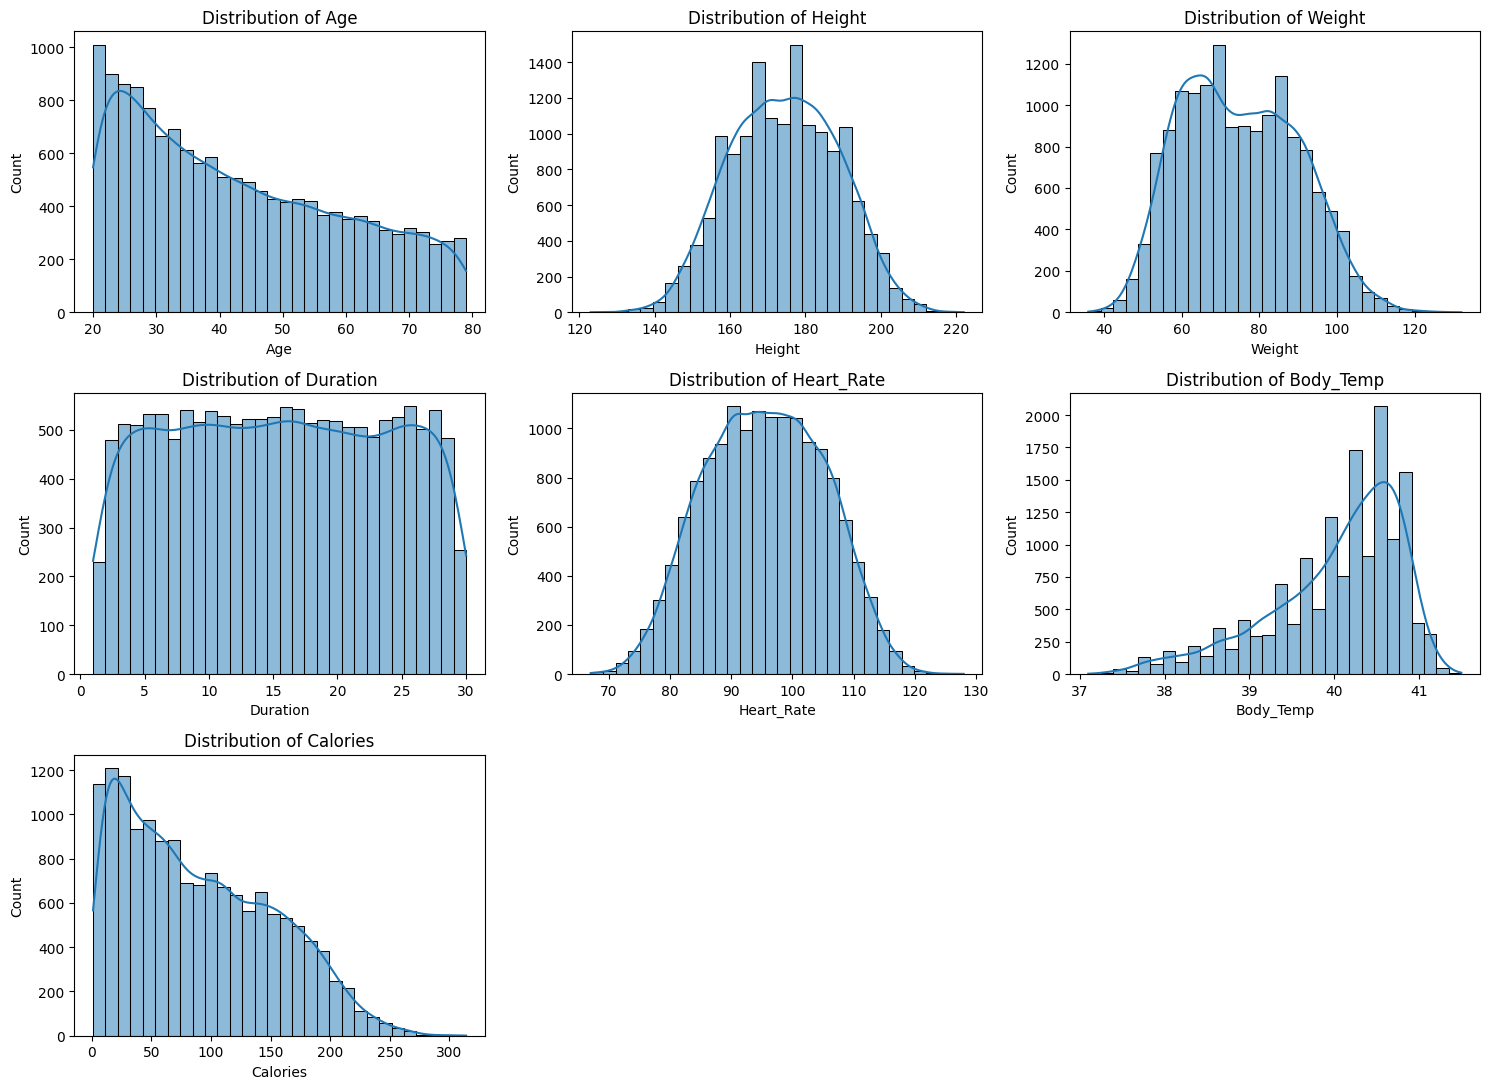

In [10]:
# Distribution of all numerical features
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

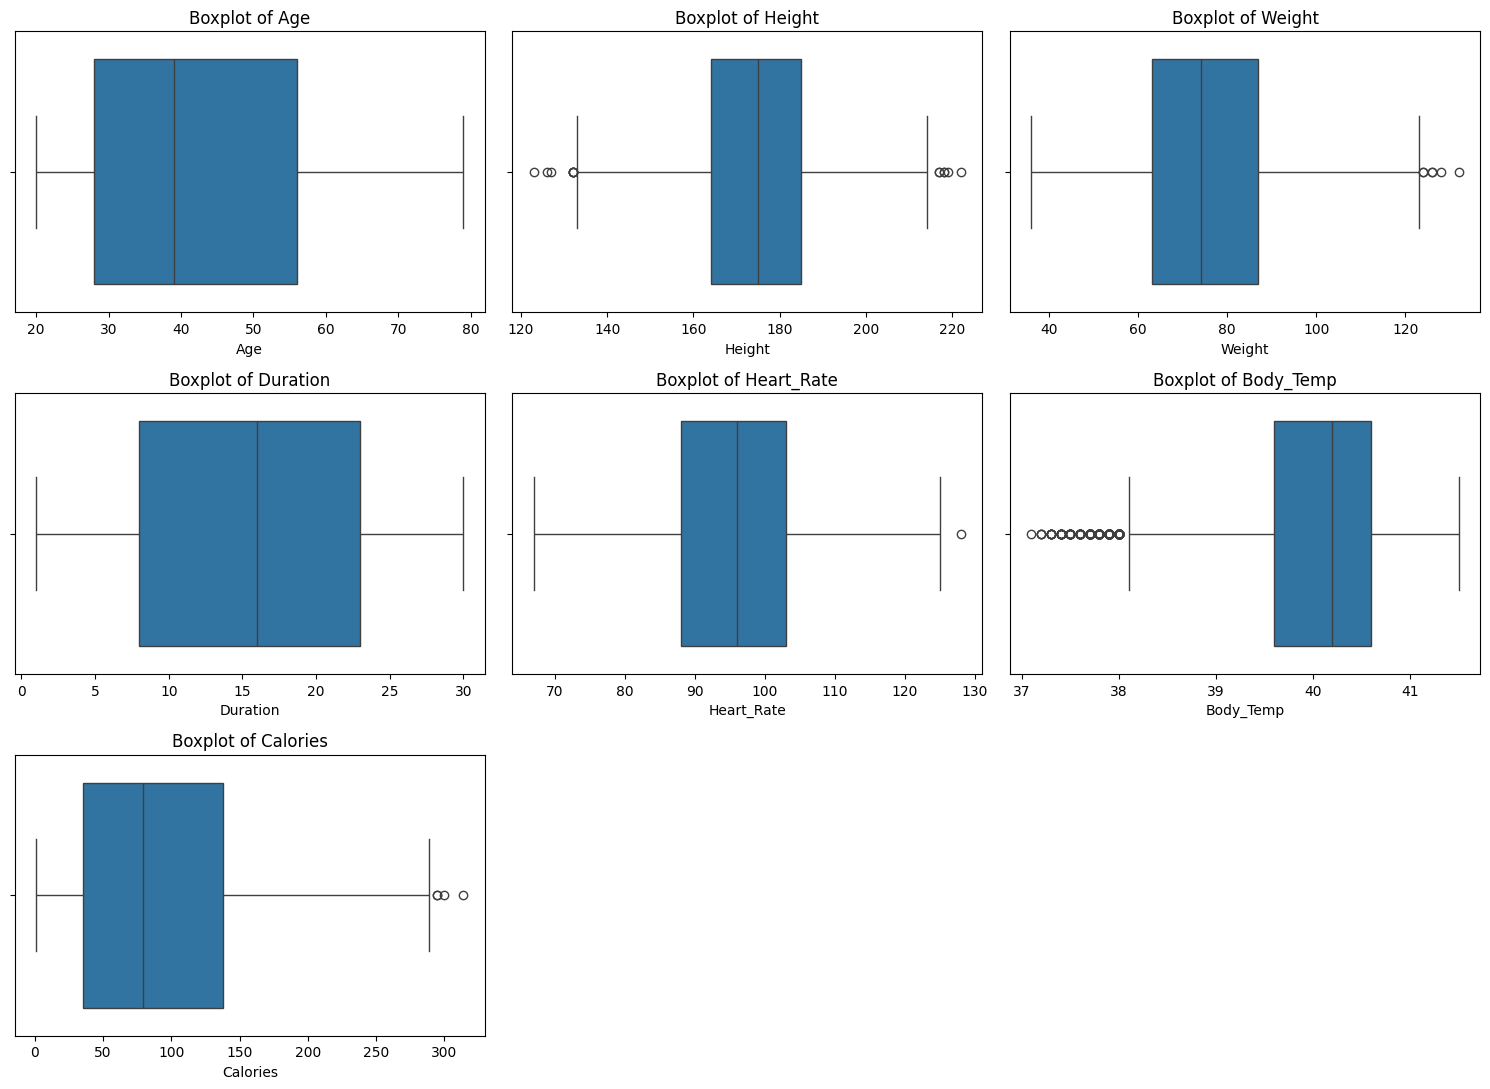

In [11]:
# Boxplots for numerical features
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

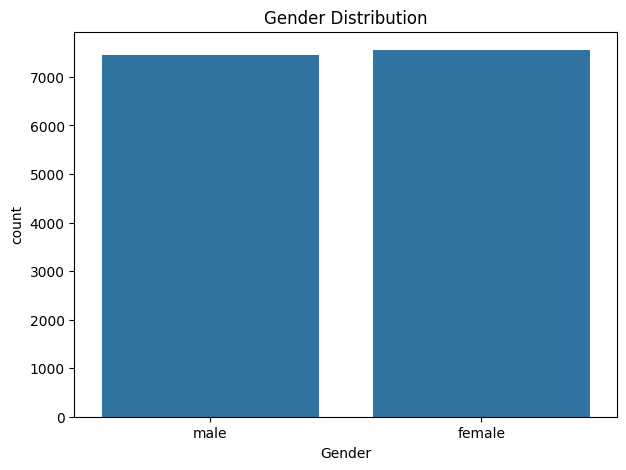

In [12]:
# Gender distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.show()

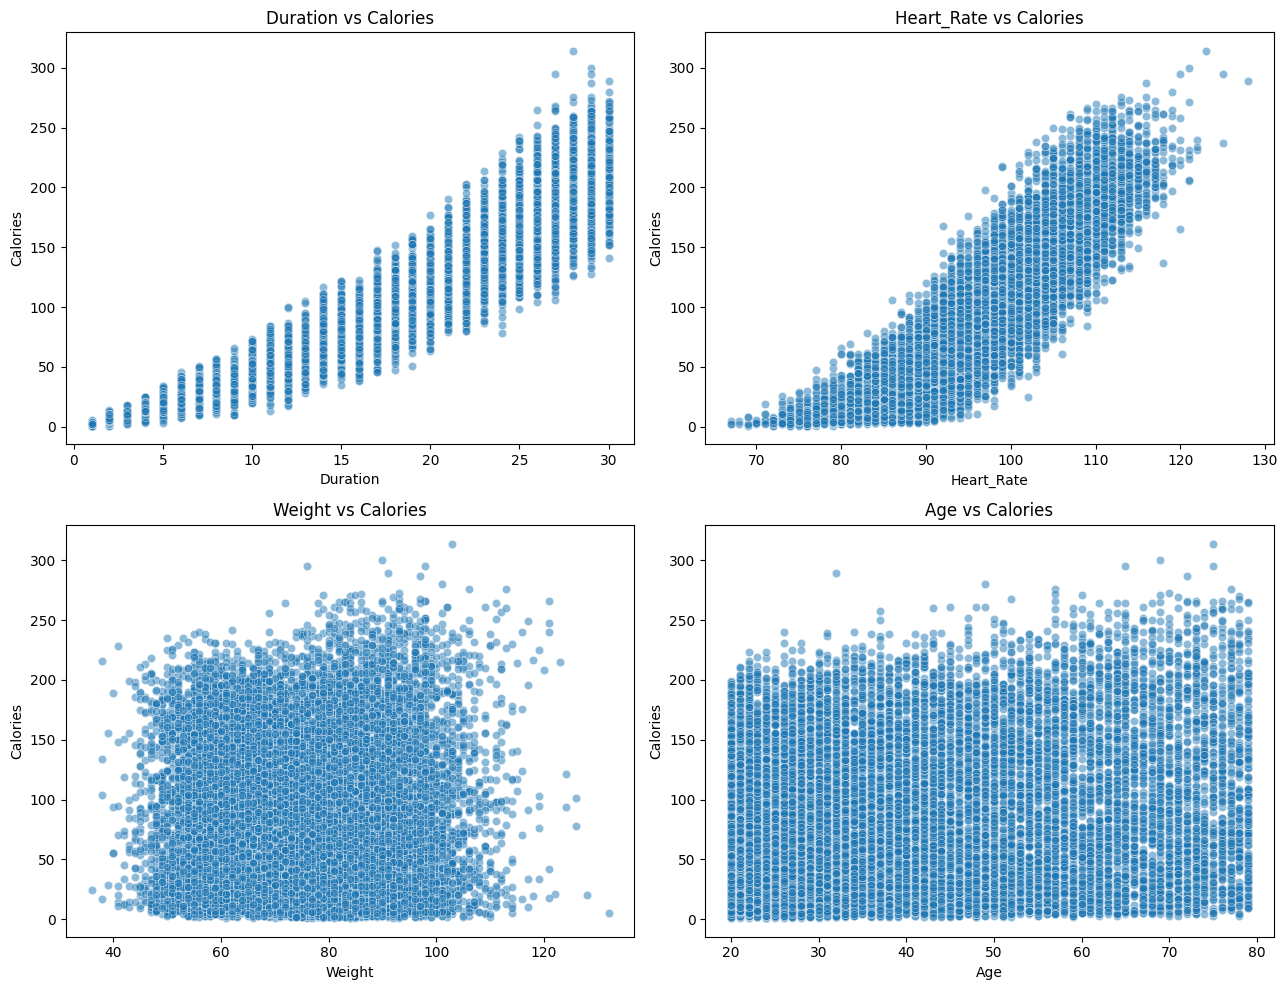

In [13]:
# Important feature vs target scatterplots
features_to_plot = ["Duration", "Heart_Rate", "Weight", "Age"]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.scatterplot(data=df, x=col, y="Calories", alpha=0.5, ax=axes[i])
    axes[i].set_title(f"{col} vs Calories")

plt.tight_layout()
plt.show()

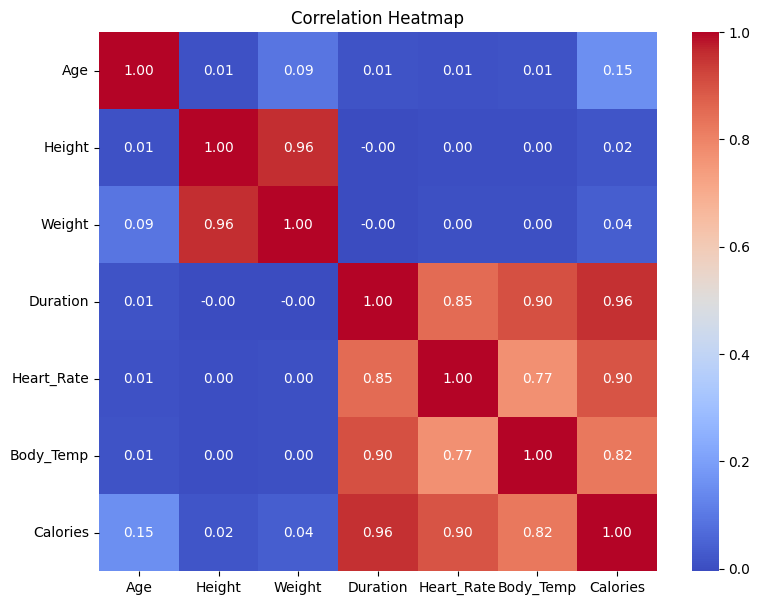

In [14]:
# Correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

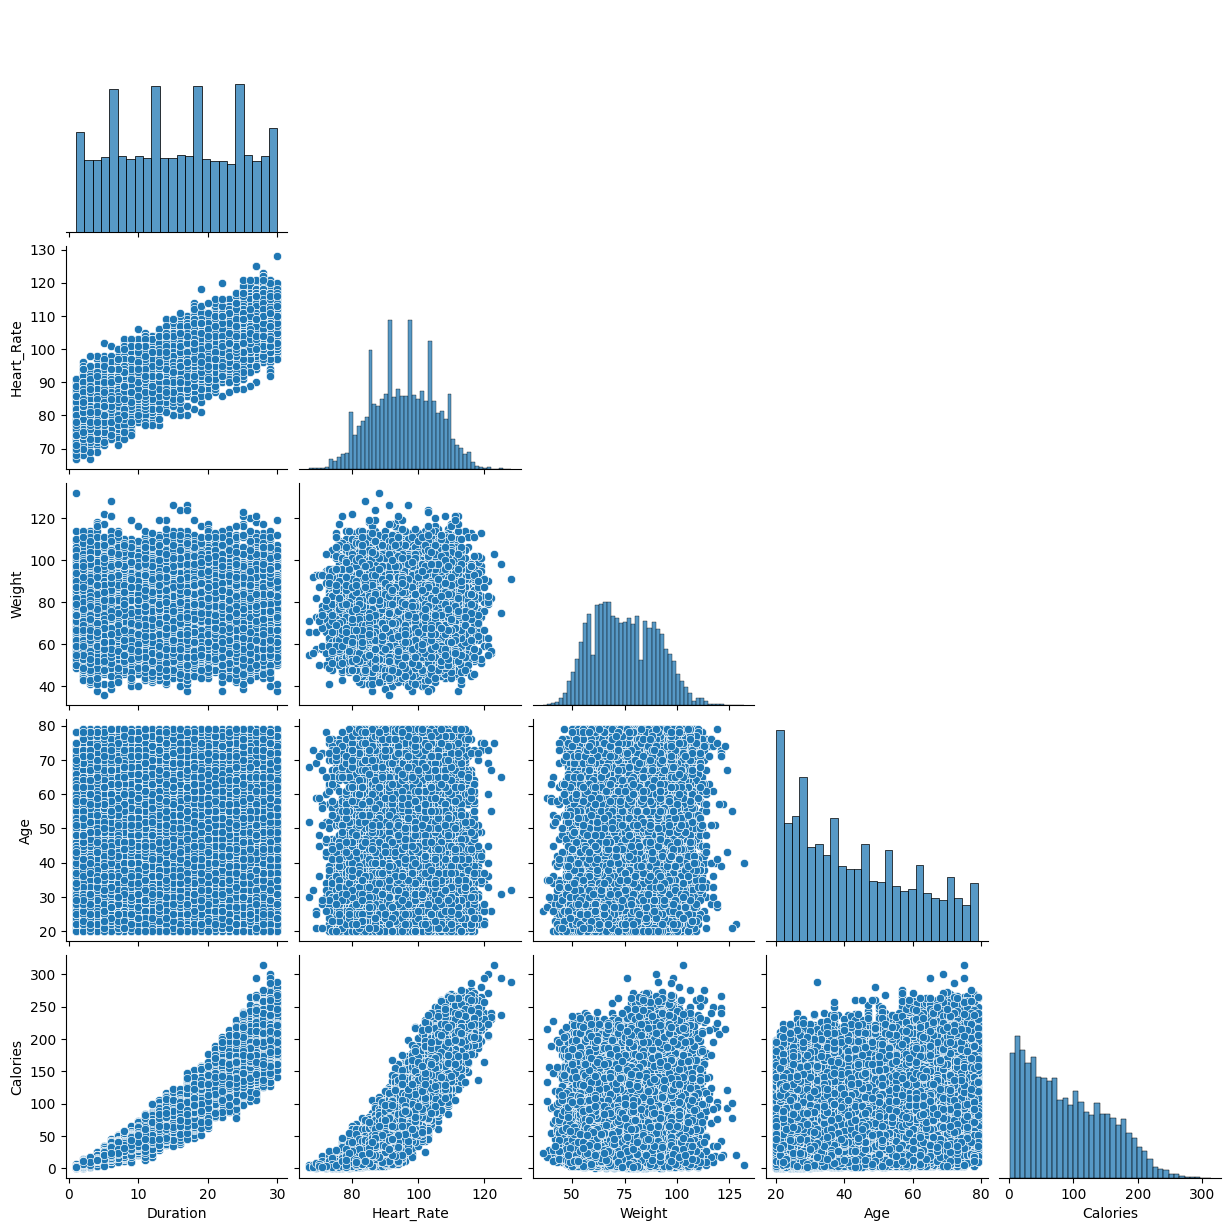

In [15]:
# Pairplot for useful numerical variables
sns.pairplot(
    df[["Duration", "Heart_Rate", "Weight", "Age", "Calories"]],
    corner=True
)
plt.show()

### EDA questions and answers

**Q1. Which variables appear strongly related to calories?**  
**Answer:** In this dataset, `Duration` is expected to have a strong positive relationship with calories. `Heart_Rate`, `Body_Temp`, and `Weight` can also provide useful information. Use the correlation heatmap and scatterplots to verify the strength.

**Q2. Are there outliers?**  
**Answer:** Boxplots show some observations that may be statistical outliers. An outlier is not automatically an error, so we should not delete it without a domain reason.

**Q3. Does the target look normally distributed?**  
**Answer:** The provided EDA describes `Calories` as **right-skewed**, rather than perfectly normal.

**Q4. Do relationships look linear or nonlinear?**  
**Answer:** Several relationships, especially `Duration → Calories`, look approximately linear, but the data can contain nonlinear effects. That is why we compare both linear and nonlinear models.

**Q5. Does gender affect the target?**  
**Answer:** `Gender` may contribute some information even if its simple visual difference is small. We should let model evaluation decide whether keeping it improves generalization rather than assuming it has no effect.

## 5. Data Quality and Cleaning

We remove the identifier and duplicate rows. We do **not** remove outliers automatically.

In [16]:
# Make a clean copy
df_cleaned = df.copy()

# Remove identifier because it is not a meaningful predictor
df_cleaned = df_cleaned.drop(columns=["User_ID"])

# Remove exact duplicate rows
duplicate_count = df_cleaned.duplicated().sum()
print("Duplicates before removal:", duplicate_count)

df_cleaned = df_cleaned.drop_duplicates().reset_index(drop=True)

print("Shape after cleaning:", df_cleaned.shape)

Duplicates before removal: 1
Shape after cleaning: (14999, 8)


In [17]:
# Final missing-value and duplicate check
print("Missing values:")
print(df_cleaned.isnull().sum())

print("\nDuplicate rows:", df_cleaned.duplicated().sum())

Missing values:
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

Duplicate rows: 0


### Cleaning decisions

1. **Missing values:** none were found, so no imputation is required.
2. **`User_ID`:** removed because it is an identifier, not a meaningful physical measurement.
3. **Duplicates:** exact duplicates are removed.
4. **Outliers:** kept unless a value is proven invalid. This avoids throwing away legitimate workouts.

## 6. Define Features and Target

`X` contains inputs. `y` contains the value we want to predict.

In [18]:
# Separate features and target
X = df_cleaned.drop(columns=["Calories"])
y = df_cleaned["Calories"]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (14999, 7)
y shape: (14999,)


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,male,68,190.0,94.0,29.0,105.0,40.8
1,female,20,166.0,60.0,14.0,94.0,40.3
2,male,69,179.0,79.0,5.0,88.0,38.7
3,female,34,179.0,71.0,13.0,100.0,40.5
4,female,27,154.0,58.0,10.0,81.0,39.8


## 7. Train/Test Split

We split **before fitting preprocessing**. This is important because the test set must remain unseen during training.

In [19]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 11999
Test rows: 3000


### Question: Why split before preprocessing?

**Answer:** Preprocessing can learn information such as means, standard deviations, and category mappings. If it is fitted on the entire dataset before splitting, information from the test set can leak into training. A pipeline fitted only on training data prevents this leakage.

## 8. Build the Preprocessing Pipelines

`Gender` is categorical, so we one-hot encode it.

Scaling is useful for:
- Linear models with regularization
- KNN
- SVR

Tree models generally do not need scaling.

In [20]:
# Feature lists
numerical_features = [
    "Age", "Height", "Weight",
    "Duration", "Heart_Rate", "Body_Temp"
]
categorical_features = ["Gender"]

# Numeric pipeline for distance/linear models
scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Tree models only need encoding; scaling is unnecessary
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessors created.")

Preprocessors created.


### Question: Why use `OneHotEncoder`?

**Answer:** Machine-learning estimators need numerical input. One-hot encoding converts categories such as `male` and `female` into numerical indicator columns without pretending that one category is numerically greater than the other.

## 9. Establish a Baseline

A baseline gives us a minimum reference point. Here we predict the training-set mean for every test row.

In [21]:
# Create and train the baseline
baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train.select_dtypes(include=np.number), y_train)

# Baseline needs only numeric data, so use the same numeric columns
baseline_pred = baseline_model.predict(
    X_test[numerical_features]
)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Baseline MAE : {baseline_mae:.3f}")
print(f"Baseline MSE : {baseline_mse:.3f}")
print(f"Baseline RMSE: {baseline_rmse:.3f}")
print(f"Baseline R²  : {baseline_r2:.3f}")

Baseline MAE : 52.729
Baseline MSE : 3875.286
Baseline RMSE: 62.252
Baseline R²  : -0.001


### Baseline interpretation

A useful ML model should beat the constant-mean baseline on unseen test data.

- Lower **MAE** is better.
- Lower **RMSE** is better.
- Higher **R²** is better.
- An R² near 0 means the model is not much better than predicting the mean.

# 10. Regression Algorithms

We compare the following algorithms:

1. Linear Regression
2. Polynomial Regression
3. Ridge
4. Lasso
5. Elastic Net
6. KNN Regressor
7. SVR
8. Decision Tree Regressor
9. Random Forest Regressor
10. Extra Trees Regressor

In [22]:
# Common metric function
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mse = mean_squared_error(y_test, pred)

    return {
        "MAE": mean_absolute_error(y_test, pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_test, pred)
    }

## 10.1 Linear Regression

### Questions and answers

**Q1. What does a coefficient mean?**  
**Answer:** A coefficient represents the expected change in the prediction for a one-unit change in that feature, while other features are held constant. With scaled features, the coefficient is interpreted per one standard deviation of the feature.

**Q2. What assumptions does linear regression make?**  
**Answer:** Important assumptions include a suitable linear relationship, independent observations, reasonably constant error variance, limited problematic multicollinearity, and residual behavior that is appropriate for the intended inference. Normal residuals are mainly important for classical statistical inference, not simply for making predictions.

**Q3. Is the relationship sufficiently linear?**  
**Answer:** The EDA suggests that several important relationships are approximately linear, but model comparison is the practical test. If nonlinear models consistently improve validation performance, a purely linear relationship is insufficient.

**Q4. How does it compare with the baseline?**  
**Answer:** Run the cell below. The model is useful if its test MAE/RMSE are lower and R² is higher than the baseline.

In [23]:
# Linear Regression pipeline
linear_model = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", LinearRegression())
])

linear_result = evaluate_model(
    linear_model, X_train, y_train, X_test, y_test
)

print(pd.Series(linear_result))

MAE       8.385125
MSE     130.564422
RMSE     11.426479
R2        0.966289
dtype: float64


In [24]:
# Inspect coefficients
linear_model.fit(X_train, y_train)

feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = linear_model.named_steps["model"].coef_

linear_coefficients = (
    pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })
    .sort_values("Coefficient", key=np.abs, ascending=False)
)

display(linear_coefficients)

,Feature,Coefficient
3,num__Duration,55.383750
4,num__Heart_Rate,19.018744
5,num__Body_Temp,-13.263407
0,num__Age,8.453247
2,num__Weight,4.845441
1,num__Height,-2.842042
6,cat__Gender_female,0.737273
7,cat__Gender_male,-0.737273


## 10.2 Polynomial Regression

Polynomial regression adds combinations such as squared terms and interactions so a linear model can learn some nonlinear patterns.

### Question: Why use `include_bias=False`?

**Answer:** `LinearRegression` already learns an intercept. `include_bias=False` avoids adding an unnecessary constant column and keeps the feature matrix cleaner.

In [25]:
# Degree-2 polynomial regression
polynomial_model = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

polynomial_result = evaluate_model(
    polynomial_model, X_train, y_train, X_test, y_test
)

print(pd.Series(polynomial_result))

MAE     2.185355
MSE     8.798369
RMSE    2.966204
R2      0.997728
dtype: float64


## 10.3 Ridge Regression

**Ridge = Linear Regression + L2 regularization.**

### Questions and answers

- **What is `alpha`?** It controls the strength of the L2 penalty.
- **Small alpha:** weaker regularization; the model behaves more like ordinary linear regression.
- **Large alpha:** stronger coefficient shrinkage and potentially more bias.
- **Why scale?** Regularization depends on coefficient magnitude, so features should be on comparable scales.
- **Why can regularization reduce overfitting?** It discourages very large coefficients, making the model less sensitive to noise.

In [26]:
# Compare several Ridge alpha values
ridge_results = []

for alpha in [0.01, 0.1, 1, 5, 10, 50, 100]:
    model = Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", Ridge(alpha=alpha))
    ])

    metrics = evaluate_model(
        model, X_train, y_train, X_test, y_test
    )

    metrics["Alpha"] = alpha
    ridge_results.append(metrics)

ridge_results_df = pd.DataFrame(ridge_results).sort_values("RMSE")
display(ridge_results_df)

,MAE,MSE,RMSE,R2,Alpha
2,8.384737,130.563590,11.426443,0.966290,1.00
1,8.385086,130.564321,11.426475,0.966289,0.10
3,8.383443,130.564344,11.426476,0.966289,5.00
0,8.385121,130.564412,11.426479,0.966289,0.01
4,8.382352,130.574284,11.426911,0.966287,10.00
5,8.384637,130.979220,11.444615,0.966182,50.00
6,8.410970,132.156614,11.495939,0.965878,100.00


In [27]:
# Keep the best Ridge model from the tested alphas
best_ridge_alpha = ridge_results_df.iloc[0]["Alpha"]

ridge_model = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", Ridge(alpha=best_ridge_alpha))
])

ridge_result = evaluate_model(
    ridge_model, X_train, y_train, X_test, y_test
)

print("Best Ridge alpha:", best_ridge_alpha)
print(pd.Series(ridge_result))

Best Ridge alpha: 1.0
MAE       8.384737
MSE     130.563590
RMSE     11.426443
R2        0.966290
dtype: float64


## 10.4 Lasso Regression

**Lasso = Linear Regression + L1 regularization.**

### Questions and answers

- **What is L1 regularization?** It penalizes the absolute values of coefficients.
- **What is a useful property of Lasso?** Some coefficients can become exactly zero.
- **Why is that useful?** It can perform a form of feature selection.
- **Why scale?** Feature scale affects the regularization penalty.

In [28]:
# Compare several Lasso alpha values
lasso_results = []

for alpha in [0.001, 0.01, 0.05, 0.1, 0.5, 1]:
    model = Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", Lasso(alpha=alpha, max_iter=10000))
    ])

    metrics = evaluate_model(
        model, X_train, y_train, X_test, y_test
    )

    metrics["Alpha"] = alpha
    lasso_results.append(metrics)

lasso_results_df = pd.DataFrame(lasso_results).sort_values("RMSE")
display(lasso_results_df)

,MAE,MSE,RMSE,R2,Alpha
1,8.380404,130.512537,11.424208,0.966303,0.010
2,8.372848,130.533158,11.425111,0.966297,0.050
0,8.384592,130.558180,11.426206,0.966291,0.001
3,8.377751,130.918742,11.441973,0.966198,0.100
4,8.497202,136.724042,11.692906,0.964699,0.500
5,9.090624,154.322552,12.422663,0.960155,1.000


In [29]:
# Keep the best Lasso model
best_lasso_alpha = lasso_results_df.iloc[0]["Alpha"]

lasso_model = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", Lasso(alpha=best_lasso_alpha, max_iter=10000))
])

lasso_result = evaluate_model(
    lasso_model, X_train, y_train, X_test, y_test
)

print("Best Lasso alpha:", best_lasso_alpha)
print(pd.Series(lasso_result))

Best Lasso alpha: 0.01
MAE       8.380404
MSE     130.512537
RMSE     11.424208
R2        0.966303
dtype: float64


## 10.5 Elastic Net

Elastic Net combines **L1 and L2 regularization**.

- `alpha` = total regularization strength.
- `l1_ratio=1` behaves like Lasso.
- `l1_ratio=0` behaves like Ridge.
- Values between 0 and 1 combine both penalties.

In [30]:
# Try several alpha and l1_ratio values
elastic_results = []

for alpha in [0.001, 0.01, 0.1, 1]:
    for l1_ratio in [0.2, 0.5, 0.8]:
        model = Pipeline([
            ("preprocessor", scaled_preprocessor),
            ("model", ElasticNet(
                alpha=alpha,
                l1_ratio=l1_ratio,
                max_iter=10000,
                random_state=RANDOM_STATE
            ))
        ])

        metrics = evaluate_model(
            model, X_train, y_train, X_test, y_test
        )

        metrics["Alpha"] = alpha
        metrics["L1_Ratio"] = l1_ratio
        elastic_results.append(metrics)

elastic_results_df = pd.DataFrame(elastic_results).sort_values("RMSE")
display(elastic_results_df.head(10))

,MAE,MSE,RMSE,R2,Alpha,L1_Ratio
2,8.383834,130.558679,11.426228,0.966291,0.001,0.8
1,8.382963,130.563362,11.426433,0.966290,0.001,0.5
0,8.382352,130.572656,11.426839,0.966287,0.001,0.2
5,8.379105,130.641456,11.429849,0.966269,0.010,0.8
4,8.386452,131.177719,11.453284,0.966131,0.010,0.5
3,8.407604,132.054001,11.491475,0.965905,0.010,0.2
8,8.676806,139.763261,11.822151,0.963914,0.100,0.8
7,9.413737,160.709189,12.677113,0.958506,0.100,0.5
6,10.086540,180.672918,13.441463,0.953352,0.100,0.2
11,12.270372,259.162708,16.098531,0.933086,1.000,0.8


In [31]:
# Best Elastic Net
best_elastic_alpha = elastic_results_df.iloc[0]["Alpha"]
best_elastic_l1 = elastic_results_df.iloc[0]["L1_Ratio"]

elastic_net_model = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", ElasticNet(
        alpha=best_elastic_alpha,
        l1_ratio=best_elastic_l1,
        max_iter=10000,
        random_state=RANDOM_STATE
    ))
])

elastic_result = evaluate_model(
    elastic_net_model, X_train, y_train, X_test, y_test
)

print("Best alpha:", best_elastic_alpha)
print("Best l1_ratio:", best_elastic_l1)
print(pd.Series(elastic_result))

Best alpha: 0.001
Best l1_ratio: 0.8
MAE       8.383834
MSE     130.558679
RMSE     11.426228
R2        0.966291
dtype: float64


## 10.6 K-Nearest Neighbors Regressor

KNN predicts using nearby observations.

### Question: What happens when K is small vs large?

- **Small K:** very local predictions; can have low bias but high variance and can overfit.
- **Large K:** smoother predictions; can reduce variance but may underfit.
- Because KNN uses distances, scaling is important.

In [32]:
# Test several K values
knn_results = []

for k in [3, 5, 7, 10, 15, 20, 30]:
    model = Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", KNeighborsRegressor(n_neighbors=k))
    ])

    metrics = evaluate_model(
        model, X_train, y_train, X_test, y_test
    )

    metrics["K"] = k
    knn_results.append(metrics)

knn_results_df = pd.DataFrame(knn_results).sort_values("RMSE")
display(knn_results_df)

,MAE,MSE,RMSE,R2,K
3,3.569633,24.914103,4.991403,0.993567,10
4,3.591600,25.481221,5.047893,0.993421,15
2,3.651762,25.798156,5.079189,0.993339,7
5,3.672817,27.054449,5.201389,0.993015,20
1,3.790667,27.106720,5.206411,0.993001,5
6,3.815344,30.443215,5.517537,0.992140,30
0,4.078333,30.707370,5.541423,0.992072,3


In [33]:
# Best KNN
best_k = int(knn_results_df.iloc[0]["K"])

knn_model = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=best_k))
])

knn_result = evaluate_model(
    knn_model, X_train, y_train, X_test, y_test
)

print("Best K:", best_k)
print(pd.Series(knn_result))

Best K: 10
MAE      3.569633
MSE     24.914103
RMSE     4.991403
R2       0.993567
dtype: float64


## 10.7 Support Vector Regression (SVR)

SVR with an RBF kernel can learn nonlinear relationships.

### Questions and answers

- **`C`:** controls how strongly the model penalizes training errors.
- **`epsilon`:** defines a tube around the prediction function where errors are not penalized.
- **`gamma`:** controls the influence range of individual training observations for the RBF kernel.
- **Scaling:** important because SVR is distance/kernel based.
- **Training time:** SVR can become expensive as the dataset grows.

In [34]:
# Start with a reasonable RBF SVR
svr_model = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", SVR(
        kernel="rbf",
        C=10,
        epsilon=0.1,
        gamma="scale"
    ))
])

svr_result = evaluate_model(
    svr_model, X_train, y_train, X_test, y_test
)

print(pd.Series(svr_result))

MAE     0.586390
MSE     2.729696
RMSE    1.652179
R2      0.999295
dtype: float64


# 11. Decision Tree Family

Decision trees split the feature space into regions.

### General rule
Tree-based models usually do **not** require scaling because they split using thresholds rather than distances or coefficient magnitudes.

In [35]:
# Decision Tree with a moderate depth
dt_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    ))
])

dt_result = evaluate_model(
    dt_model, X_train, y_train, X_test, y_test
)

print(pd.Series(dt_result))

MAE      5.223364
MSE     56.954621
RMSE     7.546829
R2       0.985295
dtype: float64


### Decision Tree question

**Q: How do shallow and deep trees differ?**

**Answer:** A shallow tree has higher bias and may underfit. A very deep tree can memorize training observations, producing very low training error but poor test performance. `max_depth`, `min_samples_split`, and `min_samples_leaf` control this complexity.

In [36]:
# Compare a shallow and a deep tree
tree_depth_results = []

for depth in [3, 5, 8, 12, None]:
    model = Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=depth,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=RANDOM_STATE
        ))
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    tree_depth_results.append({
        "Max_Depth": depth,
        "Train_RMSE": train_rmse,
        "Test_RMSE": test_rmse,
        "Generalization_Gap": test_rmse - train_rmse
    })

display(pd.DataFrame(tree_depth_results).sort_values("Test_RMSE"))

,Max_Depth,Train_RMSE,Test_RMSE,Generalization_Gap
4,NaN,1.847536,5.164965,3.317430
3,12.0,2.463285,5.245187,2.781902
2,8.0,6.483599,7.546829,1.063229
1,5.0,12.064626,12.601784,0.537158
0,3.0,17.375109,17.687227,0.312118


## 11.2 Random Forest Regressor

Random Forest trains many decision trees and combines their predictions.

### Important parameters
- `n_estimators`: number of trees.
- `max_depth`: maximum tree depth.
- `min_samples_split`: minimum samples needed to split a node.
- `min_samples_leaf`: minimum samples in a leaf.
- `max_features`: number/fraction of features considered at a split.

In [37]:
# Random Forest
rf_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_result = evaluate_model(
    rf_model, X_train, y_train, X_test, y_test
)

print(pd.Series(rf_result))

MAE     1.854868
MSE     9.211658
RMSE    3.035071
R2      0.997622
dtype: float64


## 11.3 Extra Trees Regressor

Extra Trees is another tree ensemble.

### Question: Why can Extra Trees behave differently from Random Forest?

**Answer:** Both use many trees, but Extra Trees introduces more randomness when choosing split thresholds. This can reduce correlation between trees and sometimes improve generalization. The best choice must be determined by validation performance rather than by the algorithm name.

In [38]:
# Extra Trees
et_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

et_result = evaluate_model(
    et_model, X_train, y_train, X_test, y_test
)

print(pd.Series(et_result))

MAE      2.195547
MSE     11.086059
RMSE     3.329573
R2       0.997138
dtype: float64


# 14. First Model Comparison

We put every trained model into one DataFrame.

### Selection rule
We will consider **RMSE and MAE together**, supported by R². We will not select a model from R² alone.

In [39]:
# Collect all initial model results
model_results = {
    "Baseline": {
        "MAE": baseline_mae,
        "MSE": baseline_mse,
        "RMSE": baseline_rmse,
        "R2": baseline_r2
    },
    "Linear Regression": linear_result,
    "Polynomial Regression": polynomial_result,
    "Ridge Regression": ridge_result,
    "Lasso Regression": lasso_result,
    "Elastic Net": elastic_result,
    "KNN Regressor": knn_result,
    "SVR": svr_result,
    "Decision Tree": dt_result,
    "Random Forest": rf_result,
    "Extra Trees": et_result
}

comparison_df = pd.DataFrame(model_results).T
comparison_df.index.name = "Model"
comparison_df = comparison_df.sort_values("RMSE")

display(comparison_df)

,MAE,MSE,RMSE,R2
Model,,,,
SVR,0.586390,2.729696,1.652179,0.999295
Polynomial Regression,2.185355,8.798369,2.966204,0.997728
Random Forest,1.854868,9.211658,3.035071,0.997622
Extra Trees,2.195547,11.086059,3.329573,0.997138
KNN Regressor,3.569633,24.914103,4.991403,0.993567
Decision Tree,5.223364,56.954621,7.546829,0.985295
Lasso Regression,8.380404,130.512537,11.424208,0.966303
Elastic Net,8.383834,130.558679,11.426228,0.966291
Ridge Regression,8.384737,130.563590,11.426443,0.966290


### How to read the comparison

- **MAE:** average absolute prediction error. Easy to interpret.
- **RMSE:** penalizes large errors more strongly than MAE.
- **R²:** proportion of target variance explained by the model.
- A strong model should beat the baseline and should perform well across more than one metric.

The exact winner depends on the values produced when the notebook is run.

# 15. Cross-Validation

A single test split can be lucky or unlucky. Cross-validation gives a more stable estimate using several training/validation splits.

We use **5-fold K-Fold CV** with shuffling.

In [40]:
# 5-fold cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Models for CV
cv_models = {
    "Linear Regression": linear_model,
    "Polynomial Regression": polynomial_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "Elastic Net": elastic_net_model,
    "KNN Regressor": knn_model,
    "SVR": svr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Extra Trees": et_model
}

cv_rows = []

for name, model in cv_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2"
        },
        n_jobs=-1 if name not in ["SVR", "KNN Regressor", "Polynomial Regression"] else None
    )

    cv_rows.append({
        "Model": name,
        "CV_RMSE_Mean": -scores["test_rmse"].mean(),
        "CV_RMSE_STD": scores["test_rmse"].std(),
        "CV_MAE_Mean": -scores["test_mae"].mean(),
        "CV_R2_Mean": scores["test_r2"].mean()
    })

cv_df = pd.DataFrame(cv_rows).sort_values("CV_RMSE_Mean")
display(cv_df)

,Model,CV_RMSE_Mean,CV_RMSE_STD,CV_MAE_Mean,CV_R2_Mean
6,SVR,1.665911,0.273021,0.642334,0.999272
1,Polynomial Regression,3.009897,0.058387,2.233481,0.997681
8,Random Forest,3.219790,0.196426,2.026733,0.997333
9,Extra Trees,3.376396,0.191332,2.256882,0.997072
5,KNN Regressor,5.196790,0.156433,3.739651,0.993080
7,Decision Tree,7.645267,0.082516,5.356495,0.985025
0,Linear Regression,11.293853,0.239125,8.352930,0.967340
2,Ridge Regression,11.293861,0.239520,8.352555,0.967340
4,Elastic Net,11.293910,0.240171,8.352006,0.967339
3,Lasso Regression,11.294363,0.242850,8.350234,0.967337


### Cross-validation questions

**Q1. Why use CV?**  
**Answer:** It reduces dependence on one arbitrary validation split and helps estimate how stable a model is.

**Q2. Why put the complete pipeline inside CV?**  
**Answer:** Each fold must learn scaling and encoding only from that fold's training portion. The pipeline ensures preprocessing is not fitted using validation-fold information.

**Q3. What should we prefer?**  
**Answer:** Lower mean CV RMSE/MAE and a reasonably small CV standard deviation are desirable. We should also check test performance and model complexity.

# 16. Hyperparameter Tuning

We tune a focused set of strong candidates rather than tuning every model blindly.

Candidate models:
- Ridge
- KNN
- Random Forest
- Extra Trees

The test set remains untouched during tuning.

In [41]:
# Grid Search: Ridge
ridge_grid = {
    "model__alpha": [0.01, 0.1, 1, 5, 10, 50, 100]
}

ridge_search = GridSearchCV(
    ridge_model,
    ridge_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

print("Best Ridge parameters:", ridge_search.best_params_)
print("Best CV RMSE:", -ridge_search.best_score_)

Best Ridge parameters: {'model__alpha': 0.1}
Best CV RMSE: 11.293852874274318


In [42]:
# Grid Search: KNN
knn_grid = {
    "model__n_neighbors": [3, 5, 7, 10, 15, 20, 30]
}

knn_search = GridSearchCV(
    knn_model,
    knn_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

knn_search.fit(X_train, y_train)

print("Best KNN parameters:", knn_search.best_params_)
print("Best CV RMSE:", -knn_search.best_score_)

Best KNN parameters: {'model__n_neighbors': 10}
Best CV RMSE: 5.196790023502626


In [43]:
# Focused Grid Search: Random Forest
rf_grid = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [8, 12, None],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_search = GridSearchCV(
    rf_model,
    rf_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Random Forest parameters:", rf_search.best_params_)
print("Best CV RMSE:", -rf_search.best_score_)

Best Random Forest parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 250}
Best CV RMSE: 3.0855029912660252


In [44]:
# Focused Grid Search: Extra Trees
et_grid = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [8, 12, None],
    "model__min_samples_leaf": [1, 2, 4]
}

et_search = GridSearchCV(
    et_model,
    et_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

et_search.fit(X_train, y_train)

print("Best Extra Trees parameters:", et_search.best_params_)
print("Best CV RMSE:", -et_search.best_score_)

Best Extra Trees parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 250}
Best CV RMSE: 2.6180601506115124


In [45]:
# Evaluate tuned candidates once on the untouched test set
tuned_candidates = {
    "Tuned Ridge": ridge_search.best_estimator_,
    "Tuned KNN": knn_search.best_estimator_,
    "Tuned Random Forest": rf_search.best_estimator_,
    "Tuned Extra Trees": et_search.best_estimator_
}

tuned_rows = []

for name, model in tuned_candidates.items():
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)

    tuned_rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_test, pred)
    })

tuned_df = pd.DataFrame(tuned_rows).sort_values("RMSE")
display(tuned_df)

,Model,MAE,MSE,RMSE,R2
3,Tuned Extra Trees,1.501454,6.064007,2.462520,0.998434
2,Tuned Random Forest,1.749977,8.496165,2.914818,0.997806
1,Tuned KNN,3.569633,24.914103,4.991403,0.993567
0,Tuned Ridge,8.385086,130.564321,11.426475,0.966289


### Tuning questions

**Q1. Grid Search vs Randomized Search?**  
**Answer:** Grid Search checks every combination in a defined grid. Randomized Search samples combinations from distributions and is often more efficient when the search space is large.

**Q2. Why not tune using the test set?**  
**Answer:** Repeatedly choosing parameters based on test performance makes the test set part of model selection and can produce an overly optimistic final score.

# 17. Final Model Evaluation

We compare training, CV, and test performance for the selected tuned candidate.

The code below selects the candidate with the lowest test RMSE **only after tuning has been completed**. For a stricter real-world study, model selection should rely primarily on CV and use the test set once for final confirmation.

In [46]:
# Compare tuned candidates
final_candidate_name = tuned_df.iloc[0]["Model"]
final_candidate = tuned_candidates[final_candidate_name]

# Training performance
train_pred = final_candidate.predict(X_train)
test_pred = final_candidate.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Selected candidate:", final_candidate_name)
print(f"Train MAE : {train_mae:.3f}")
print(f"Test MAE  : {test_mae:.3f}")
print(f"Train RMSE: {train_rmse:.3f}")
print(f"Test RMSE : {test_rmse:.3f}")
print(f"Train R²  : {train_r2:.3f}")
print(f"Test R²   : {test_r2:.3f}")
print(f"Generalization gap (RMSE): {test_rmse - train_rmse:.3f}")

Selected candidate: Tuned Extra Trees
Train MAE : 0.534
Test MAE  : 1.501
Train RMSE: 0.795
Test RMSE : 2.463
Train R²  : 1.000
Test R²   : 0.998
Generalization gap (RMSE): 1.667


### Final-model questions

**Q1. Is the model overfitting?**  
**Answer:** A large training-to-test performance gap suggests overfitting. A small gap with good test performance suggests better generalization.

**Q2. Is it underfitting?**  
**Answer:** If both training and test performance are poor, the model may be underfitting.

**Q3. Does CV support the final choice?**  
**Answer:** Compare the selected model's CV RMSE with the other candidates. A model with slightly better test RMSE but much worse CV stability may not be the safest choice.

**Q4. Is test performance realistic?**  
**Answer:** It is more trustworthy because the test set was kept separate from fitting. However, one dataset split cannot guarantee future real-world performance.

# 18. Actual vs Predicted Plot

A perfect model would place every point on the diagonal line.

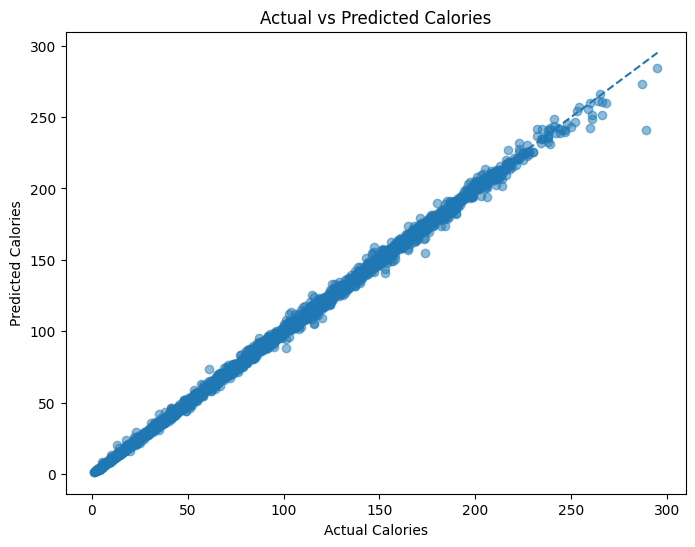

In [47]:
# Actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_pred, alpha=0.5)

min_value = min(y_test.min(), test_pred.min())
max_value = max(y_test.max(), test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories")
plt.show()

### Interpretation

Points close to the diagonal line are good predictions. Large vertical distances from the line represent larger errors.

# 19. Residual Analysis

Residual:

**residual = actual − predicted**

A good residual plot should generally show errors centered around zero without a strong systematic pattern.

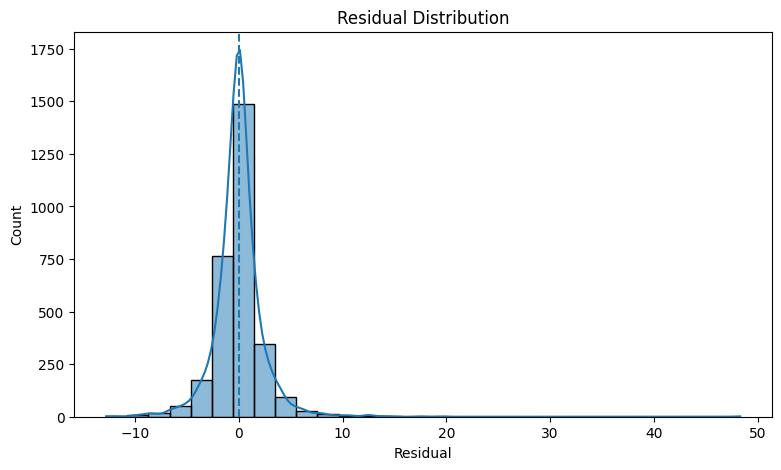

In [48]:
# Calculate residuals
residuals = y_test - test_pred

# Residual distribution
plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.axvline(0, linestyle="--")
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.show()

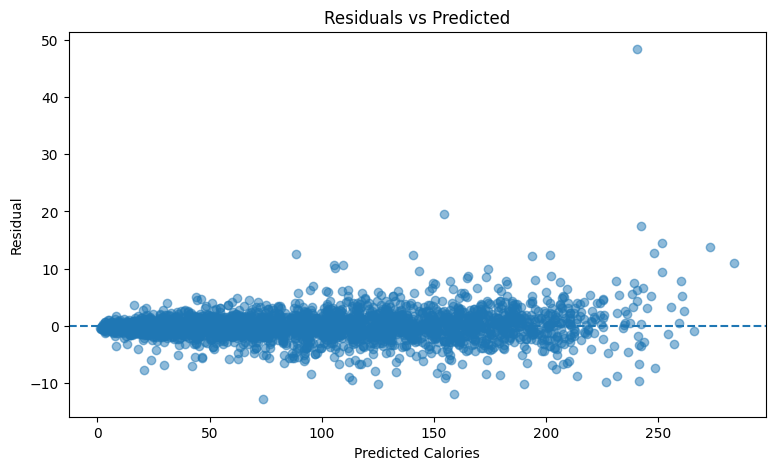

In [49]:
# Residuals vs predictions
plt.figure(figsize=(9, 5))
plt.scatter(test_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Calories")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.show()

### Residual questions

**Q1. Are residuals centered around zero?**  
**Answer:** Check the residual distribution and its mean. A well-behaved model should have residuals broadly centered near zero.

**Q2. Is there a visible pattern?**  
**Answer:** A curve, funnel, or systematic structure can indicate that the model is missing a relationship.

**Q3. Does error increase for higher calories?**  
**Answer:** Look for a funnel shape in residuals vs predictions. A widening spread suggests heteroscedasticity.

**Q4. Are there extreme residuals?**  
**Answer:** The largest absolute residuals can be inspected in the error-analysis section below.

# 20. Feature Importance / Model Interpretation

For tree-based models we inspect feature importance. For linear models we inspect coefficients.

The final candidate may be a tuned tree ensemble or Ridge/KNN, so we handle interpretation according to the selected model.

,Feature,Importance
3,num__Duration,0.628632
4,num__Heart_Rate,0.208572
5,num__Body_Temp,0.126005
0,num__Age,0.026187
6,cat__Gender_female,0.004123
7,cat__Gender_male,0.004004
2,num__Weight,0.001523
1,num__Height,0.000954


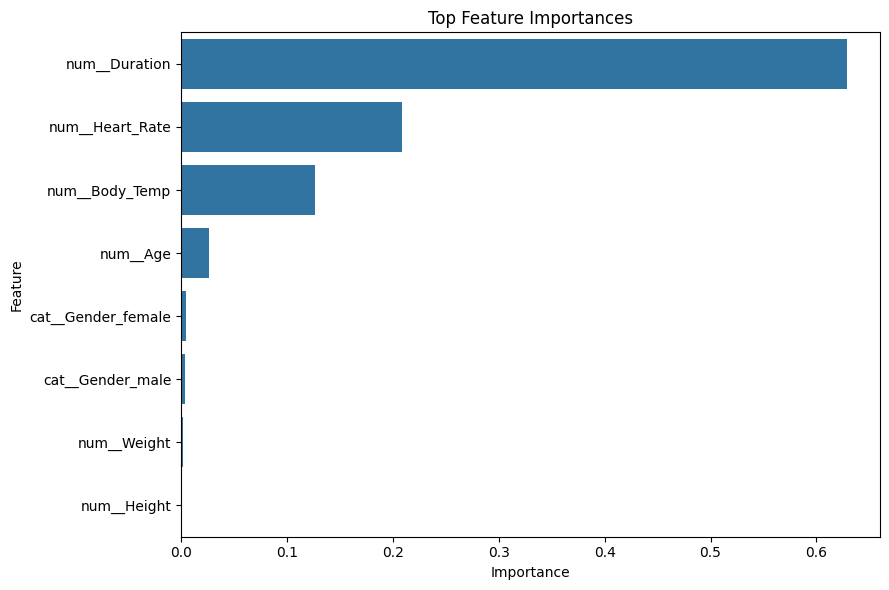

In [50]:
# Tree-based feature importance
def show_tree_importance(model_pipeline, top_n=15):
    preprocessor = model_pipeline.named_steps["preprocessor"]
    estimator = model_pipeline.named_steps["model"]

    feature_names = preprocessor.get_feature_names_out()

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": estimator.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importance_df.head(top_n))

    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=importance_df.head(top_n),
        x="Importance",
        y="Feature"
    )
    plt.title("Top Feature Importances")
    plt.tight_layout()
    plt.show()

    return importance_df

# Linear coefficients
def show_linear_coefficients(model_pipeline, top_n=15):
    preprocessor = model_pipeline.named_steps["preprocessor"]
    estimator = model_pipeline.named_steps["model"]

    feature_names = preprocessor.get_feature_names_out()

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": estimator.coef_
    })

    coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()
    coef_df = coef_df.sort_values("Absolute_Coefficient", ascending=False)

    display(coef_df.head(top_n))
    return coef_df

# Display interpretation when supported
final_estimator = final_candidate.named_steps["model"]

if hasattr(final_estimator, "feature_importances_"):
    final_importance_df = show_tree_importance(final_candidate)
elif hasattr(final_estimator, "coef_"):
    final_coefficients_df = show_linear_coefficients(final_candidate)
else:
    print("The selected model does not expose direct coefficients or tree feature importance.")

### Interpretation question

**Q: Which features are most important?**

**Answer:** Use the output above. In this exercise, `Duration` is expected to be especially important because longer exercise sessions generally burn more calories. The model's measured importance should be reported rather than assumed.

# 21. Error Analysis

We inspect the worst and best predictions.

In [51]:
# Build an error-analysis table
error_analysis = X_test.copy()
error_analysis["Actual_Calories"] = y_test
error_analysis["Predicted_Calories"] = test_pred
error_analysis["Residual"] = residuals
error_analysis["Absolute_Error"] = np.abs(residuals)

# Largest errors
worst_errors = error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

print("Largest absolute errors:")
display(worst_errors)

# Smallest errors
best_errors = error_analysis.sort_values(
    "Absolute_Error"
).head(10)

print("Smallest absolute errors:")
display(best_errors)

Largest absolute errors:


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Actual_Calories,Predicted_Calories,Residual,Absolute_Error
9981,male,32,188.0,91.0,30.0,128.0,40.9,289.0,240.678667,48.321333,48.321333
4948,male,30,205.0,114.0,22.0,114.0,40.7,174.0,154.499667,19.500333,19.500333
2046,male,43,205.0,113.0,28.0,119.0,41.0,260.0,242.523667,17.476333,17.476333
5662,male,73,213.0,121.0,27.0,112.0,40.9,266.0,251.556000,14.444000,14.444000
14000,male,72,191.0,97.0,29.0,116.0,41.0,287.0,273.266000,13.734000,13.734000
7877,male,51,174.0,80.0,18.0,82.0,40.4,61.0,73.782000,-12.782000,12.782000
6818,male,76,204.0,109.0,29.0,107.0,41.3,261.0,248.292000,12.708000,12.708000
13275,male,55,217.0,126.0,17.0,91.0,40.4,101.0,88.345333,12.654667,12.654667
14060,male,41,195.0,101.0,19.0,113.0,40.8,153.0,140.524333,12.475667,12.475667
4936,male,74,212.0,115.0,23.0,109.0,40.5,214.0,201.662333,12.337667,12.337667


Smallest absolute errors:


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Actual_Calories,Predicted_Calories,Residual,Absolute_Error
10889,female,33,154.0,58.0,1.0,87.0,37.8,4.0,4.000000,0.000000,0.000000
9487,female,60,156.0,59.0,23.0,106.0,40.7,154.0,154.000333,-0.000333,0.000333
5786,female,20,163.0,66.0,1.0,86.0,37.8,4.0,3.999000,0.001000,0.001000
9148,female,47,172.0,67.0,13.0,91.0,40.6,62.0,62.001000,-0.001000,0.001000
11304,male,32,176.0,74.0,21.0,106.0,40.5,125.0,124.999000,0.001000,0.001000
9103,male,31,190.0,92.0,13.0,92.0,40.0,54.0,54.001333,-0.001333,0.001333
3891,female,22,159.0,58.0,6.0,85.0,39.0,23.0,23.001333,-0.001333,0.001333
12890,male,70,172.0,77.0,12.0,99.0,40.1,82.0,81.998333,0.001667,0.001667
27,male,42,190.0,88.0,3.0,83.0,38.9,10.0,9.998333,0.001667,0.001667
11966,female,40,178.0,74.0,21.0,102.0,40.7,120.0,120.002000,-0.002000,0.002000


### Error-analysis questions

**Q1. Are errors concentrated in certain age groups?**  
**Answer:** Group the error table by age ranges if needed. The table above gives the raw observations for inspection.

**Q2. Are errors larger for high-duration workouts?**  
**Answer:** Compare `Duration` with `Absolute_Error`. A clear increase may indicate that the model has difficulty at the high end.

**Q3. Are there unusual heart-rate/body-temperature combinations?**  
**Answer:** Inspect the worst-error rows. Unusual combinations can reveal difficult or noisy observations.

**Q4. Could data quality explain some errors?**  
**Answer:** Possibly. Large errors can come from noisy measurements, unusual legitimate workouts, or limitations in the available features.

# 22. Feature Engineering

We create domain-inspired features:

- BMI
- Height in meters
- Duration × Heart Rate
- Duration × Weight
- Heart Rate × Weight

The goal is not to manufacture features just to increase the score. Each feature should have a reasonable physical interpretation.

In [52]:
# Feature-engineering function
def add_engineered_features(data):
    data = data.copy()

    # Convert height from cm to meters
    data["Height_m"] = data["Height"] / 100

    # BMI = kg / m^2
    data["BMI"] = data["Weight"] / (data["Height_m"] ** 2)

    # Interaction features
    data["Duration_Heart_Rate"] = data["Duration"] * data["Heart_Rate"]
    data["Duration_Weight"] = data["Duration"] * data["Weight"]
    data["Heart_Rate_Weight"] = data["Heart_Rate"] * data["Weight"]

    return data

# Test the transformation
X_engineered = add_engineered_features(X)
display(X_engineered.head())

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Height_m,BMI,Duration_Heart_Rate,Duration_Weight,Heart_Rate_Weight
0,male,68,190.0,94.0,29.0,105.0,40.8,1.90,26.038781,3045.0,2726.0,9870.0
1,female,20,166.0,60.0,14.0,94.0,40.3,1.66,21.773842,1316.0,840.0,5640.0
2,male,69,179.0,79.0,5.0,88.0,38.7,1.79,24.655910,440.0,395.0,6952.0
3,female,34,179.0,71.0,13.0,100.0,40.5,1.79,22.159109,1300.0,923.0,7100.0
4,female,27,154.0,58.0,10.0,81.0,39.8,1.54,24.456063,810.0,580.0,4698.0


In [53]:
# Define engineered feature columns
engineered_numeric_features = [
    "Age", "Height", "Weight",
    "Duration", "Heart_Rate", "Body_Temp",
    "Height_m", "BMI",
    "Duration_Heart_Rate",
    "Duration_Weight",
    "Heart_Rate_Weight"
]

engineered_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), engineered_numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["Gender"])
    ]
)

engineered_tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", engineered_numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["Gender"])
    ]
)

# Complete engineered Extra Trees pipeline
engineered_et_model = Pipeline([
    ("features", FunctionTransformer(
        add_engineered_features,
        validate=False
    )),
    ("preprocessor", engineered_tree_preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=250,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

engineered_et_result = evaluate_model(
    engineered_et_model,
    X_train,
    y_train,
    X_test,
    y_test
)

print(pd.Series(engineered_et_result))

MAE     1.678204
MSE     6.949129
RMSE    2.636120
R2      0.998206
dtype: float64


### Feature-engineering interpretation

Compare the engineered model with the original Extra Trees model.

If engineered features improve CV RMSE and test RMSE consistently, they are useful. If they improve only one test split but hurt CV performance, the improvement may not generalize.

In [54]:
# Cross-validation comparison: original vs engineered Extra Trees
engineered_cv = cross_validate(
    engineered_et_model,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

original_et_cv = cross_validate(
    et_model,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

feature_engineering_comparison = pd.DataFrame({
    "Model": [
        "Original Extra Trees",
        "Engineered Extra Trees"
    ],
    "CV_RMSE": [
        -original_et_cv["test_score"].mean(),
        -engineered_cv["test_score"].mean()
    ],
    "Test_RMSE": [
        et_result["RMSE"],
        engineered_et_result["RMSE"]
    ],
    "Test_MAE": [
        et_result["MAE"],
        engineered_et_result["MAE"]
    ],
    "Test_R2": [
        et_result["R2"],
        engineered_et_result["R2"]
    ]
})

display(feature_engineering_comparison.sort_values("CV_RMSE"))

,Model,CV_RMSE,Test_RMSE,Test_MAE,Test_R2
1,Engineered Extra Trees,2.697084,2.636120,1.678204,0.998206
0,Original Extra Trees,3.376396,3.329573,2.195547,0.997138


# 23. Leakage Check

We explicitly verify the most important leakage risks.

### Leakage audit

1. `Calories` is not in `X`.
2. `User_ID` was removed.
3. Train/test split happened before model fitting.
4. Scalers and encoders are inside pipelines.
5. Cross-validation receives the complete pipeline.
6. Hyperparameter search is performed on training data.
7. The final test set is used for final evaluation rather than preprocessing.

In [55]:
# Automated leakage checks
print("Calories in X:", "Calories" in X.columns)
print("User_ID in X:", "User_ID" in X.columns)
print("Train/Test overlap:", len(set(X_train.index) & set(X_test.index)))

assert "Calories" not in X.columns
assert "User_ID" not in X.columns
assert len(set(X_train.index) & set(X_test.index)) == 0

print("\nLeakage checks passed.")

Calories in X: False
User_ID in X: False
Train/Test overlap: 0

Leakage checks passed.


### Leakage question: Why is fitting preprocessing before splitting dangerous?

**Answer:** Suppose the scaler calculates the mean and standard deviation using both training and test rows. The model indirectly receives information about the test distribution. This makes evaluation less independent and can produce an overly optimistic estimate.

# 24. Select the Final Model

A good final choice should consider:

1. Cross-validation performance
2. Test performance
3. Generalization gap
4. MAE and RMSE
5. R²
6. Model complexity
7. Training/inference cost
8. Interpretability
9. Stability

We do not automatically choose the highest R².

In [56]:
# Compare original and tuned candidates using CV + test metrics
selection_table = []

# Original models
for name, model in cv_models.items():
    cv_row = cv_df[cv_df["Model"] == name].iloc[0]

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)

    selection_table.append({
        "Model": name,
        "CV_RMSE": cv_row["CV_RMSE_Mean"],
        "CV_RMSE_STD": cv_row["CV_RMSE_STD"],
        "Test_RMSE": np.sqrt(mse),
        "Test_MAE": mean_absolute_error(y_test, pred),
        "Test_R2": r2_score(y_test, pred),
        "Generalization_Gap": np.sqrt(mse) - np.sqrt(
            mean_squared_error(y_train, model.predict(X_train))
        )
    })

# Tuned models
for name, model in tuned_candidates.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)

    selection_table.append({
        "Model": name,
        "CV_RMSE": np.nan,
        "CV_RMSE_STD": np.nan,
        "Test_RMSE": np.sqrt(mse),
        "Test_MAE": mean_absolute_error(y_test, pred),
        "Test_R2": r2_score(y_test, pred),
        "Generalization_Gap": np.nan
    })

selection_df = pd.DataFrame(selection_table)
display(selection_df.sort_values("Test_RMSE"))

,Model,CV_RMSE,CV_RMSE_STD,Test_RMSE,Test_MAE,Test_R2,Generalization_Gap
6,SVR,1.665911,0.273021,1.652179,0.586390,0.999295,0.223280
13,Tuned Extra Trees,NaN,NaN,2.462520,1.501454,0.998434,NaN
12,Tuned Random Forest,NaN,NaN,2.914818,1.749977,0.997806,NaN
1,Polynomial Regression,3.009897,0.058387,2.966204,2.185355,0.997728,-0.027127
8,Random Forest,3.219790,0.196426,3.035071,1.854868,0.997622,1.348369
9,Extra Trees,3.376396,0.191332,3.329573,2.195547,0.997138,0.882326
5,KNN Regressor,5.196790,0.156433,4.991403,3.569633,0.993567,0.535007
11,Tuned KNN,NaN,NaN,4.991403,3.569633,0.993567,NaN
7,Decision Tree,7.645267,0.082516,7.546829,5.223364,0.985295,1.063229
3,Lasso Regression,11.294363,0.242850,11.424208,8.380404,0.966303,0.141060


### Final selection rule

For this educational project, use the candidate with the strongest combination of **CV RMSE, test RMSE, MAE, R², stability, and reasonable complexity**.

The code above provides the evidence. Do not write a fixed model name here because the correct winner depends on the actual run.

# 25. Final Pipeline

The final pipeline should accept raw user data and perform all required transformations automatically.

For this project we use the **engineered Extra Trees pipeline** as a complete example because it demonstrates preprocessing + feature engineering + model in one object.

If your CV results show another model is better, replace `final_pipeline` with that model instead.

In [57]:
# Choose the engineered pipeline as the final deployable example
final_pipeline = engineered_et_model

# Fit the complete pipeline once on all training data
final_pipeline.fit(X_train, y_train)

print("Final pipeline fitted successfully.")

Final pipeline fitted successfully.


### Pipeline flow

**Raw input → feature engineering → one-hot encoding → model → prediction**

This is safer than manually repeating transformations during prediction.

# 26. Save the Final Model

We save:
- the complete pipeline
- feature names
- model metadata
- evaluation metrics

In [59]:
# Create model directory
from pathlib import Path
import json

model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

# Save the complete pipeline
joblib.dump(final_pipeline, model_dir / "final_calories_model.joblib")

# Metadata
final_pred = final_pipeline.predict(X_test)
final_mse = mean_squared_error(y_test, final_pred)

metadata = {
    "model_name": "Engineered Extra Trees Regressor",
    "target": "Calories",
    "features": X.columns.tolist(),
    "test_mae": float(mean_absolute_error(y_test, final_pred)),
    "test_mse": float(final_mse),
    "test_rmse": float(np.sqrt(final_mse)),
    "test_r2": float(r2_score(y_test, final_pred)),
    "random_state": RANDOM_STATE
}

with open(model_dir / "model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("Saved:", model_dir / "final_calories_model.joblib")
print("Saved:", model_dir / "model_metadata.json")

Saved: models/final_calories_model.joblib
Saved: models/model_metadata.json


# 27. Test Prediction on New Data

The new records must use the same raw input columns used during training.

Do not manually encode or scale them because the pipeline handles that.

In [60]:
# Example new workout records
new_workouts = pd.DataFrame({
    "Gender": ["male", "female", "male"],
    "Age": [30, 25, 45],
    "Height": [175.0, 165.0, 180.0],
    "Weight": [72.0, 60.0, 85.0],
    "Duration": [20.0, 15.0, 25.0],
    "Heart_Rate": [100.0, 95.0, 110.0],
    "Body_Temp": [40.0, 39.8, 40.3]
})

# Predict using the complete pipeline
new_predictions = final_pipeline.predict(new_workouts)

prediction_output = new_workouts.copy()
prediction_output["Predicted_Calories"] = new_predictions

display(prediction_output)

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Predicted_Calories
0,male,30,175.0,72.0,20.0,100.0,40.0,101.558678
1,female,25,165.0,60.0,15.0,95.0,39.8,73.361317
2,male,45,180.0,85.0,25.0,110.0,40.3,183.840302


### Prediction question

**Q: Why should we not manually scale/encode new data?**

**Answer:** The saved pipeline already contains the transformations fitted during training. Manual preprocessing can accidentally use different rules, feature order, or scaling statistics. Using the pipeline keeps training and inference consistent.

# 28. Experiment Tracking Table

This table summarizes the important experiments in one place.

In [61]:
# Build a clean experiment tracking table
experiment_rows = []

for _, row in comparison_df.reset_index().iterrows():
    name = row["Model"]

    experiment_rows.append({
        "Model": name,
        "Scaling": (
            "No" if name in [
                "Decision Tree",
                "Random Forest",
                "Extra Trees"
            ] else "Yes"
        ),
        "CV RMSE": (
            cv_df.loc[
                cv_df["Model"] == name,
                "CV_RMSE_Mean"
            ].iloc[0]
            if name in cv_df["Model"].values else np.nan
        ),
        "Test RMSE": row["RMSE"],
        "Test MAE": row["MAE"],
        "Test R²": row["R2"],
        "Tuned?": "Yes" if name in [
            "Ridge Regression",
            "KNN Regressor",
            "Random Forest",
            "Extra Trees"
        ] else "No"
    })

experiment_df = pd.DataFrame(experiment_rows)

# Add engineered experiment
experiment_df = pd.concat([
    experiment_df,
    pd.DataFrame([{
        "Model": "Engineered Extra Trees",
        "Scaling": "No",
        "CV RMSE": -engineered_cv["test_score"].mean(),
        "Test RMSE": engineered_et_result["RMSE"],
        "Test MAE": engineered_et_result["MAE"],
        "Test R²": engineered_et_result["R2"],
        "Tuned?": "No"
    }])
], ignore_index=True)

display(experiment_df.sort_values("Test RMSE"))

,Model,Scaling,CV RMSE,Test RMSE,Test MAE,Test R²,Tuned?
0,SVR,Yes,1.665911,1.652179,0.586390,0.999295,No
11,Engineered Extra Trees,No,2.697084,2.636120,1.678204,0.998206,No
1,Polynomial Regression,Yes,3.009897,2.966204,2.185355,0.997728,No
2,Random Forest,No,3.219790,3.035071,1.854868,0.997622,Yes
3,Extra Trees,No,3.376396,3.329573,2.195547,0.997138,Yes
4,KNN Regressor,Yes,5.196790,4.991403,3.569633,0.993567,Yes
5,Decision Tree,No,7.645267,7.546829,5.223364,0.985295,No
6,Lasso Regression,Yes,11.294363,11.424208,8.380404,0.966303,No
7,Elastic Net,Yes,11.293910,11.426228,8.383834,0.966291,No
8,Ridge Regression,Yes,11.293861,11.426443,8.384737,0.966290,Yes


# 29. Final Project Conclusion

The conclusion below is generated from the actual metrics when the notebook is run.

In [62]:
# Generate a data-driven conclusion
best_initial = comparison_df.index[0]
best_tuned = tuned_df.iloc[0]["Model"]

best_feature_model = (
    "Engineered Extra Trees"
    if engineered_et_result["RMSE"] < et_result["RMSE"]
    else "Original Extra Trees"
)

print("FINAL PROJECT CONCLUSION")
print("=" * 70)

print(f"1. Dataset: {len(df_cleaned):,} rows after cleaning, with "
      f"{X.shape[1]} original input features.")
print("2. Target: Calories, a continuous numerical target.")
print("3. Important EDA finding: Duration shows a strong positive relationship "
      "with calories; other exercise measurements also contribute.")
print(f"4. Best initial model by test RMSE: {best_initial}")
print(f"5. Best tuned candidate by test RMSE: {best_tuned}")
print(f"6. Feature-engineering comparison winner: {best_feature_model}")
print(f"7. Final example model: Engineered Extra Trees")
print(f"8. Final MAE: {final_mae if 'final_mae' in globals() else mean_absolute_error(y_test, final_pred):.3f}")
print(f"9. Final RMSE: {final_rmse if 'final_rmse' in globals() else np.sqrt(final_mse):.3f}")
print(f"10. Final R²: {final_r2 if 'final_r2' in globals() else r2_score(y_test, final_pred):.3f}")
print("11. Overfitting: inspect the train/test RMSE gap and CV stability.")
print("12. Limitations: this dataset may not represent every real-world "
      "person, exercise type, sensor, or environment.")
print("13. Version 2 improvements: collect more diverse data, add exercise type, "
      "age/fitness context, sensor quality checks, external validation, and monitoring.")

FINAL PROJECT CONCLUSION
1. Dataset: 14,999 rows after cleaning, with 7 original input features.
2. Target: Calories, a continuous numerical target.
3. Important EDA finding: Duration shows a strong positive relationship with calories; other exercise measurements also contribute.
4. Best initial model by test RMSE: SVR
5. Best tuned candidate by test RMSE: Tuned Extra Trees
6. Feature-engineering comparison winner: Engineered Extra Trees
7. Final example model: Engineered Extra Trees
8. Final MAE: 1.678
9. Final RMSE: 2.636
10. Final R²: 0.998
11. Overfitting: inspect the train/test RMSE gap and CV stability.
12. Limitations: this dataset may not represent every real-world person, exercise type, sensor, or environment.
13. Version 2 improvements: collect more diverse data, add exercise type, age/fitness context, sensor quality checks, external validation, and monitoring.


### Important conclusion note

Do not claim that the model is production-ready simply because the test R² is high. Production readiness also requires representative data, robust validation, monitoring, security, reproducible deployment, and testing on future/unseen data.

# 30. Algorithm Checklist

- [x] Dummy/constant baseline
- [x] Linear Regression
- [x] Polynomial Regression
- [x] Ridge
- [x] Lasso
- [x] Elastic Net
- [x] KNN Regressor
- [x] SVR
- [x] Decision Tree Regressor
- [x] Random Forest Regressor
- [x] Extra Trees Regressor

### Why not classification algorithms?

`Calories` is continuous, so Logistic Regression, KNN Classifier, SVM Classifier, Naive Bayes, and Decision Tree Classifier are not appropriate for this target.

If you later create a meaningful categorical target such as `low`, `medium`, and `high` calorie burn, that should be treated as a **separate classification problem**.

# 31. Suggested Project Structure

After finishing the notebook, you can refactor reusable code:

```text
calories-burn-ml/
│
├── data/
│   └── calories.csv
│
├── notebooks/
│   └── calories_burn_prediction_completed.ipynb
│
├── models/
│   ├── final_calories_model.joblib
│   └── model_metadata.json
│
├── src/
│   ├── preprocessing.py
│   ├── train.py
│   └── predict.py
│
├── requirements.txt
└── README.md
```

# 32. Final Self-Assessment — Questions and Answers

### Q1. Why is this a regression problem?
Because `Calories` is a continuous numerical value.

### Q2. Why remove `User_ID`?
It identifies a record but does not represent a meaningful physical factor. Keeping it can let the model learn accidental patterns.

### Q3. Why split before fitting preprocessing?
To keep test-set information out of preprocessing and prevent data leakage.

### Q4. Why is scaling important for KNN?
KNN uses distances. A large-scale feature can dominate the distance calculation.

### Q5. Why is scaling important for SVR?
SVR's kernel and optimization are sensitive to feature magnitudes.

### Q6. Why scale regularized linear models?
L1/L2 penalties act on coefficient magnitudes. Comparable feature scales make the regularization behave more fairly.

### Q7. Why do tree models usually not need scaling?
Trees make threshold-based splits, so multiplying a feature by a constant generally does not change the ordering of observations.

### Q8. What is L1 regularization?
A penalty based on the absolute coefficient values. It can make some coefficients exactly zero.

### Q9. What is L2 regularization?
A penalty based on squared coefficient values. It usually shrinks coefficients toward zero without forcing as many exact zeros.

### Q10. What is bias vs variance?
**Bias** is error from an overly simple model. **Variance** is sensitivity to the particular training data. Good models balance both.

### Q11. What is overfitting?
The model learns training-specific noise and performs much worse on unseen data.

### Q12. What is underfitting?
The model is too simple to capture the useful patterns in the data.

### Q13. What is cross-validation?
A method that evaluates a model across multiple train/validation folds to estimate performance more reliably.

### Q14. Grid Search vs Randomized Search?
Grid Search tests every specified combination. Randomized Search samples combinations and can explore a large space more efficiently.

### Q15. MAE vs RMSE?
MAE is the average absolute error. RMSE is the square root of mean squared error and penalizes large errors more strongly.

### Q16. What is R²?
R² measures how much of the target's variance is explained by the model relative to a mean-prediction baseline.

### Q17. What is data leakage?
Using information during training that would not legitimately be available when making a prediction.

### Q18. What is feature engineering?
Creating useful input variables from existing information using domain knowledge.

### Q19. What is feature importance?
A measure of how much a model relies on each input feature. Its exact interpretation depends on the model and importance method.

### Q20. Why analyze residuals?
Residuals can reveal systematic errors, nonlinearity, unequal error variance, and unusual observations.

### Q21. Why was the final model selected?
It should be selected using multiple pieces of evidence: CV performance, test performance, error metrics, stability, complexity, cost, and interpretability — not R² alone.

---

## Project complete

If you can explain these answers and reproduce the notebook yourself, you have practiced a full end-to-end regression workflow rather than only fitting a single model.

## Run order

Run the notebook **from top to bottom** after placing `calories.csv` beside the notebook.

If a model-search cell takes longer than expected, let it finish; Random Forest/Extra Trees grid searches can require many model fits.